In [117]:
# install necessary modules
import sys
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install --upgrade torch torchvision
!{sys.executable} -m pip install opencv-python matplotlib
!{sys.executable} -m pip install 'git+https://github.com/facebookresearch/segment-anything.git'
!{sys.executable} -m pip install ultralytics

#!curl -o sam_vit_h_4b8939.pth https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 MB 36.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 34.7 MB/s eta 0:00:0000:01
  Attempting uninstall: torch
    Found existing installation: torch 2.3.1
    Uninstalling torch-2.3.1:
      Successfully uninstalled torch-2.3.1
  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.18.1
    Uninstalling torchvision-0.18.1:
      Successfully uninstalled torchvision-0.18.1
  Cloning https://github.com/facebookresearch/segment-anything.git to /private/var/folders/s7/vf054wld4d31cr3ltwm243cr0000gn/T/pip-req-build-0lrtfgn7
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /private/var/folders/s7/vf054wld4d31cr3ltwm243cr0000gn/T/pip-req-build-0lrtfgn7
  Resolved https://github.com/facebookresearch/segment-anything.git to commit 6fdee8f2727f4506cfbbe553e23b895e27956588
  Preparing metadata (setup.py) ... done


In [118]:
# import

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import torch
import torchvision
from ultralytics import YOLO

detect_model = YOLO("yolov8n.pt")

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
print("Mac M1+ Metal is available:", torch.backends.mps.is_available())
print("MKL is available:", torch.backends.mkl.is_available())

PyTorch version: 2.3.1
Torchvision version: 0.18.1
CUDA is available: False
Mac M1+ Metal is available: True
MKL is available: False


In [119]:
# load SAM

sys.path.append("..")
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

#sam_checkpoint = "checkpoints/sam_vit_b_01ec64.pth"
sam_checkpoint = "checkpoints/sam_vit_l_0b3195.pth"
model_type = "vit_l"

#default
device = "cpu"

#NVIDIA
#device = "cuda"

#M1 chips
#device = "mps"

sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam.to(device=device)

mask_generator = SamAutomaticMaskGenerator(sam)

In [120]:
# dev functions (use debug=True in process_image)

def show_masks(masks):
    for mask in masks:
        plt.figure(figsize=(20, 20))
    
        # Access the 'segmentation' key to get the mask
        segmentation_mask = mask['segmentation']
    
        # Display the segmentation mask
        plt.imshow(segmentation_mask, cmap='gray')
        plt.axis('off')
        plt.show()
        print(mask['area'])

def show_anns(anns):
    if len(anns) == 0:
        return
    sorted_anns = sorted(anns, key=(lambda x: x['area']), reverse=True)
    ax = plt.gca()
    ax.set_autoscale_on(False)

    img = np.ones((sorted_anns[0]['segmentation'].shape[0], sorted_anns[0]['segmentation'].shape[1], 4))
    img[:,:,3] = 0
    for ann in sorted_anns:
        m = ann['segmentation']
        color_mask = np.concatenate([np.random.random(3), [0.35]])
        img[m] = color_mask
    ax.imshow(img)

In [157]:
# additional functions

def find_glasses(masks, debug=False):
    for mask in masks:
        segmentation = mask['segmentation']
        segmentation = (segmentation * 255).astype(np.uint8)
        segmentation = cv2.cvtColor(segmentation, cv2.COLOR_GRAY2RGB)
    
        
        results = detect_model(source=segmentation)

    
        
        for result in results:
            for box in result.boxes:
                class_id = int(box.cls)
                label = result.names[class_id]
                if label == 'toothbrush':
                    if debug:
                        print('frame found')
                        plt.figure(figsize=(20,20))
                        plt.imshow(segmentation, cmap='gray')
                        plt.axis('off')
                        plt.show()
                    return mask
                
    return None

def remove_masks(image, masks):
    # Ensure the image is in RGBA mode
    image = Image.fromarray(image).convert("RGBA")
    
    # Create an array to hold the result
    result_image = np.array(image)

    # Iterate over each mask and clear the corresponding area in result_image
    for mask in masks:
        # Assuming mask["segmentation"] is a binary mask where True indicates the area to be masked
        binary_mask = mask["segmentation"].astype(bool)

        # Set the masked area in result_image to transparent
        result_image[binary_mask] = [0, 0, 0, 0]  # RGBA: Transparent
      
    # Convert result_image back to Image object
    result_image = Image.fromarray(result_image)

    # Save or return the result image (depending on your needs)
    return result_image

![Знімок екрана 2024-07-28 о 13.53.45.png](<attachment:Знімок екрана 2024-07-28 о 13.53.45.png>)
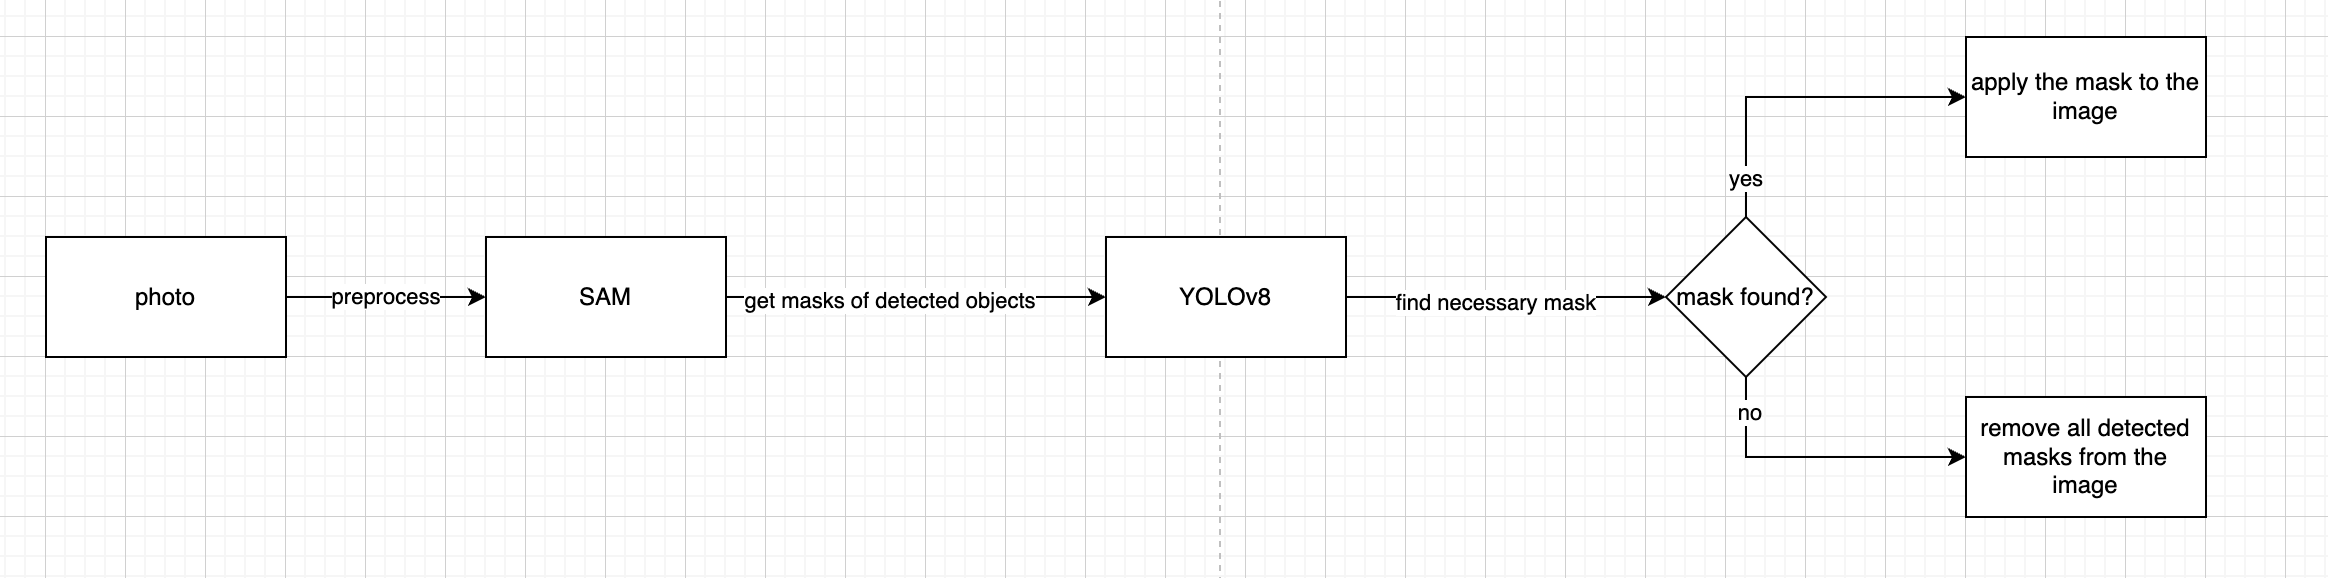

In [158]:
def process_image(image, debug=False):
    new_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    masks = mask_generator.generate(new_image)
    
    if debug:
        show_masks(masks)
        show_anns(masks)
        
    final_mask = find_glasses(masks, debug)
    
    if(final_mask is None):
        result = remove_masks(image, masks)
        
    else:
        # apply and to selected mask and image
        
        binary_mask = final_mask['segmentation'].astype(np.uint8)

        result = cv2.bitwise_and(image, image, mask=binary_mask)
    
    # remove accidental pixels

    
    return result
    


0: 640x640 (no detections), 159.4ms
Speed: 10.9ms preprocess, 159.4ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 108.1ms
Speed: 2.5ms preprocess, 108.1ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 toothbrush, 106.8ms
Speed: 2.2ms preprocess, 106.8ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)


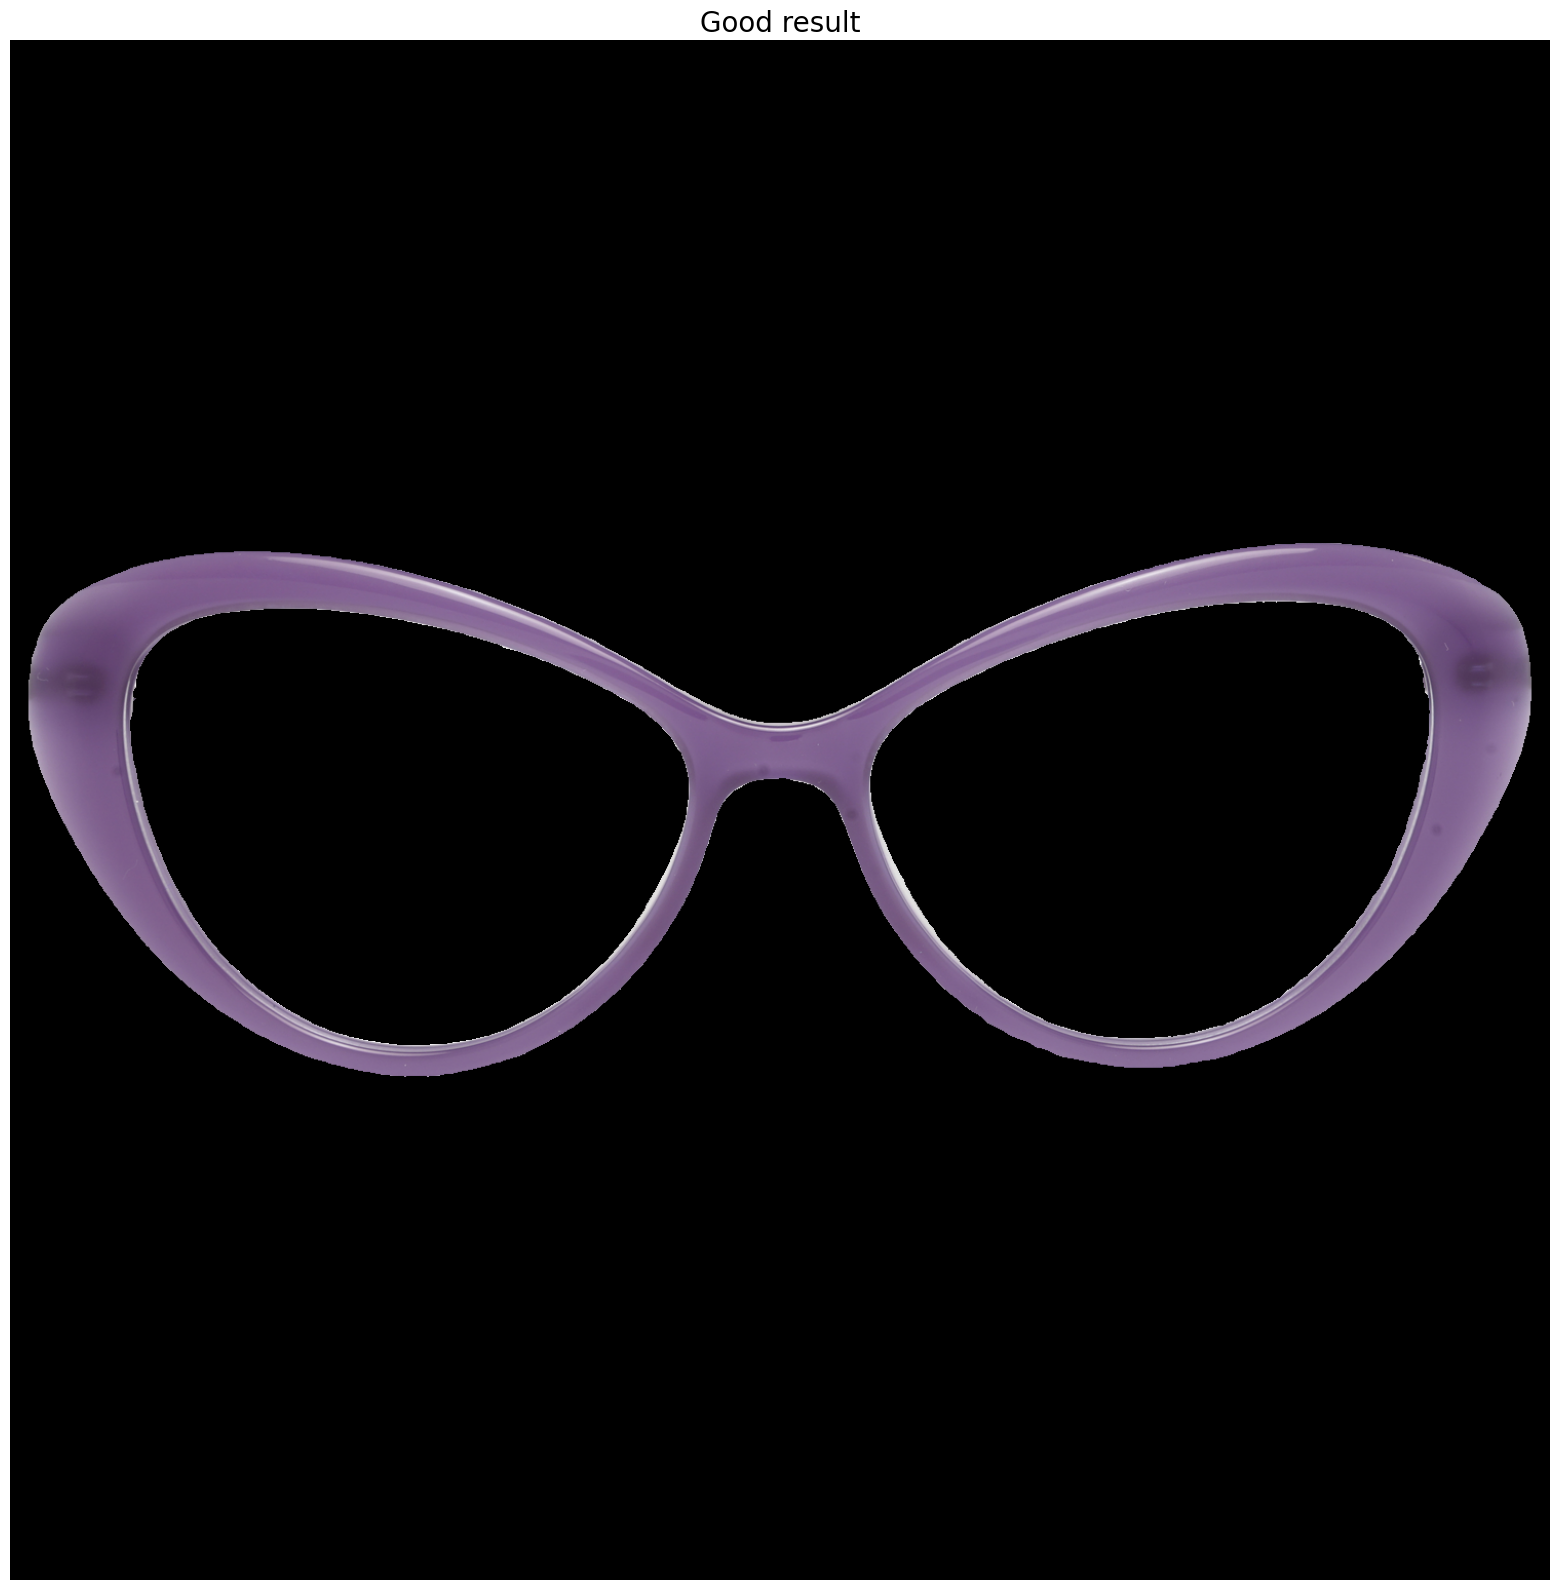


0: 640x640 (no detections), 116.3ms
Speed: 3.1ms preprocess, 116.3ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 100.9ms
Speed: 3.6ms preprocess, 100.9ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 103.4ms
Speed: 2.8ms preprocess, 103.4ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 120.0ms
Speed: 2.1ms preprocess, 120.0ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 103.6ms
Speed: 2.0ms preprocess, 103.6ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 person, 101.9ms
Speed: 2.1ms preprocess, 101.9ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 1 kite, 100.4ms
Speed: 2.2ms preprocess, 100.4ms inference, 0.4ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 (no detections), 100.9ms
Speed: 2.4ms preprocess, 100.9ms i

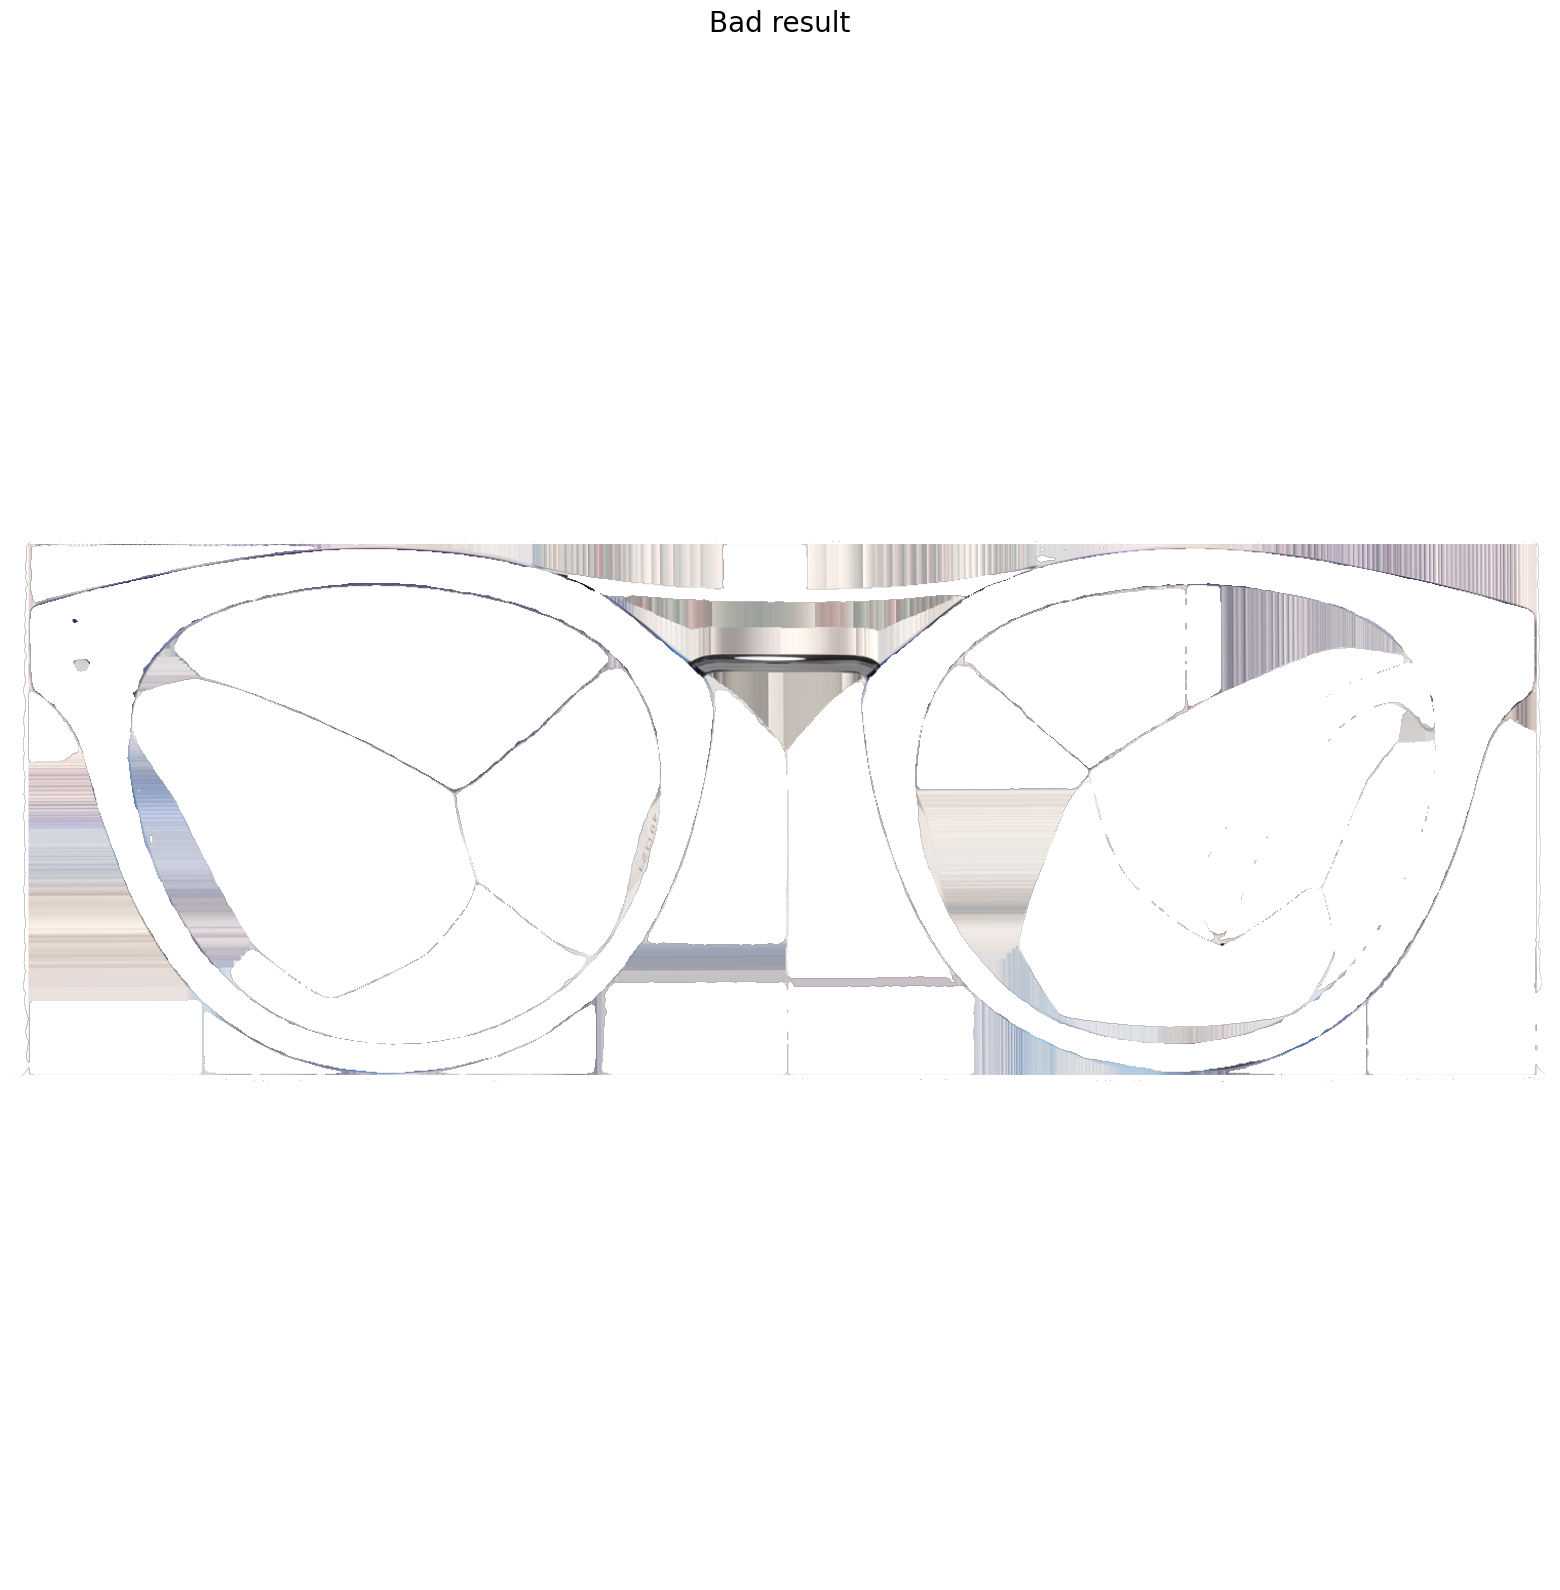

In [161]:
# example usage
image = cv2.imread("images/190605173640_01.png")
result = process_image(image)

plt.figure(figsize=(20,20))
plt.title('Good result', fontsize=20)
plt.imshow(result)
plt.axis('off')
plt.show()

image = cv2.imread("images/190605154304_01.png")
result = process_image(image)

plt.figure(figsize=(20,20))
plt.title('Bad result', fontsize=20)
plt.imshow(result)
plt.axis('off')
plt.show()